# Semana 3 — Exploración inicial del dataset OULAD

En esta etapa se realiza una exploración inicial del dataset OULAD con el propósito de comprender la estructura de los datos, identificar variables relevantes y detectar posibles problemas de calidad de datos.

El análisis exploratorio constituye una fase fundamental dentro del desarrollo de modelos de Machine Learning, ya que permite conocer el comportamiento de la información antes del preprocesamiento y modelado.

## Importación de librerías

Se importan las librerías necesarias para la manipulación, análisis y visualización de datos.

In [134]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carga del dataset

Se carga el archivo `studentInfo.csv`, perteneciente al dataset OULAD, el cual contiene información académica y demográfica de estudiantes de educación superior en entornos virtuales de aprendizaje.

In [135]:
# Cargar dataset
df = pd.read_csv("../data/studentInfo.csv")

## Visualización inicial del dataset

Se muestran las primeras filas del conjunto de datos para comprender la estructura general de las variables.

In [136]:
# Ver primeras filas
df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


Las primeras filas permiten identificar la estructura general del dataset y observar variables relacionadas con características demográficas, académicas y resultados finales de los estudiantes.

## Dimensiones del dataset

Se analiza la cantidad de registros y variables presentes en el conjunto de datos.

In [137]:
# Dimensiones del dataset
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 32593
Columnas: 12


El dataset contiene múltiples registros de estudiantes y diversas variables que podrán utilizarse para el análisis predictivo del rendimiento académico.

## Tipos de datos

Se identifican los tipos de datos de cada variable para determinar el tratamiento adecuado durante el preprocesamiento.

In [138]:
# Tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


Se observa la presencia de variables numéricas y categóricas. Además, algunas columnas presentan valores nulos, lo cual indica la necesidad de aplicar técnicas de limpieza y tratamiento de datos.

## Variables disponibles

Se muestran las variables disponibles dentro del dataset.

In [139]:
# Columnas
list(df.columns)

['code_module',
 'code_presentation',
 'id_student',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_of_prev_attempts',
 'studied_credits',
 'disability',
 'final_result']

Las variables disponibles incluyen información demográfica, nivel educativo, historial académico y resultado final del estudiante.

## Creación de la variable objetivo

La variable `final_result` será transformada en una variable binaria para abordar el problema como una tarea de clasificación supervisada.

Clasificación utilizada:

- 1 → Estudiantes aprobados (`Pass`, `Distinction`)
- 0 → Estudiantes no aprobados (`Fail`, `Withdrawn`)

In [140]:
# Crear variable objetivo binaria
df['target'] = df['final_result'].map({
    'Pass': 1,
    'Distinction': 1,
    'Fail': 0,
    'Withdrawn': 0
})

## Distribución de la variable objetivo

Se analiza la cantidad de estudiantes aprobados y no aprobados.

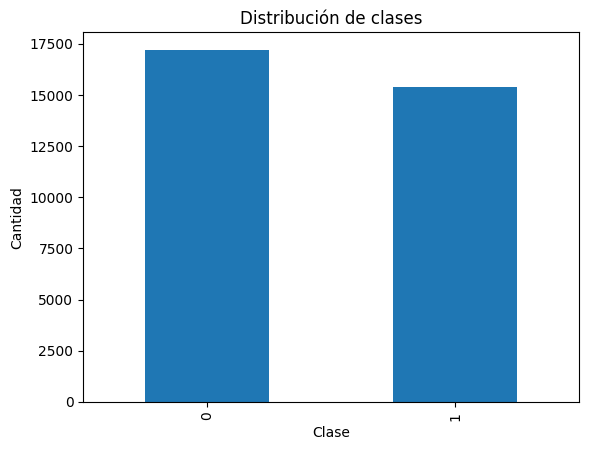

In [141]:
# Ver distribución de la variable objetivo
df['target'].value_counts().plot(kind='bar')

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

La distribución de clases permite observar la proporción de estudiantes aprobados y no aprobados.

Este análisis es importante debido a que un desbalance significativo puede afectar el rendimiento de los modelos de Machine Learning.

## Verificación de valores nulos

Se identifican las variables que contienen datos faltantes dentro del dataset.

In [142]:
# Verificar valores nulos
df.isnull().sum()

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
target                     0
dtype: int64

Se identifico la variable ´imd_band´ con presencia de valores faltantes, el cual deberá ser tratado mediante técnicas de imputación o limpieza

## Estadísticas descriptivas

Se calculan estadísticas generales para comprender el comportamiento de las variables del dataset.

In [143]:
# Estadísticas descriptivas
df.describe(include='all')

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target
count,32593,32593,3.259300e+04,32593,32593,32593,31482,32593,32593.000000,32593.000000,32593,32593,32593.000000
unique,7,4,NaN,2,13,5,10,3,NaN,NaN,2,4,NaN
top,BBB,2014J,NaN,M,Scotland,A Level or Equivalent,20-30%,0-35,NaN,NaN,N,Pass,NaN
freq,7909,11260,NaN,17875,3446,14045,3654,22944,NaN,NaN,29429,12361,NaN
mean,NaN,NaN,7.066877e+05,NaN,NaN,NaN,NaN,NaN,0.163225,79.758691,NaN,NaN,0.472034
std,NaN,NaN,5.491673e+05,NaN,NaN,NaN,NaN,NaN,0.479758,41.071900,NaN,NaN,0.499225
min,NaN,NaN,3.733000e+03,NaN,NaN,NaN,NaN,NaN,0.000000,30.000000,NaN,NaN,0.000000
25%,NaN,NaN,5.085730e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN,0.000000
50%,NaN,NaN,5.903100e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN,0.000000
75%,NaN,NaN,6.444530e+05,NaN,NaN,NaN,NaN,NaN,0.000000,120.000000,NaN,NaN,1.000000


Las estadísticas descriptivas permiten conocer características generales de las variables, incluyendo frecuencias, medias, valores máximos y mínimos.

Este análisis facilita la identificación preliminar de posibles valores atípicos o distribuciones no balanceadas.

# Conclusiones de la Semana 3

Durante esta etapa se realizó una exploración inicial del dataset OULAD, permitiendo comprender la estructura general de los datos y las variables disponibles para el análisis del rendimiento académico.

Además, se identificó la presencia de variables categóricas y numéricas, valores faltantes y una distribución específica de la variable objetivo, aspectos que deberán considerarse en las siguientes etapas del proyecto.

Este análisis inicial servirá como base para las fases posteriores de limpieza, análisis visual y preparación de datos para modelos de Machine Learning.